# ADP / ACD (Adaptive Critic Designs) on ImprovedB747Env

This notebook demonstrates an **Adaptive Critic Design (ACD)** example on:

- `tensoraerospace.envs.b747.ImprovedB747Env`

The ACD agent learns to control pitch angle tracking using adaptive dynamic programming with neural network function approximators.

In [1]:
import numpy as np

try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "PyTorch is required to run this notebook.\n"
        "Install it first (see https://pytorch.org/get-started/locally/), then restart the kernel."
    ) from exc

import matplotlib.pyplot as plt

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.agent import ADP

print("torch:", torch.__version__)



2026-01-09 04:31:21.454986: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-09 04:31:21.455014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-09 04:31:21.455890: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-09 04:31:21.461053: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 04:31:22.232678: W tensorflow/compiler/tf2

torch: 2.8.0+cu128


In [ ]:
# User controls (правь тут)

# --- Environment ---
DT = 0.1
N_STEPS = 300  # number_time_steps in env
REWARD_MODE = "tracking"  # "tracking" or "step_response"
INITIAL_STATE = np.array([0.0, 0.0, 0.0, 0.0], dtype=float)  # [u, w, q, theta]

# Sinus reference (pitch)
SINE_AMP_DEG = 1.0
SINE_FREQ_HZ = 0.05
SINE_PHASE_DEG = 0.0
SINE_OFFSET_DEG = 0.0

# --- ADP/ACD agent ---
# Paper-accurate ACD ladder (Prokhorov & Wunsch):
#  - "adhdp": ADHDP / action-dependent HDP (DDPG-like TD on Q(s,a))
#  - "dhp":   DHP  (critic learns lambda=dJ/dR)
#  - "gdhp":  GDHP (critic learns J and lambda, Fig. 5)
#  - "addhp": ADDHP (action-dependent DHP; gradients wrt (R,A))
#  - "adgdhp": ADGDHP (action-dependent GDHP, Fig. 7)
#  - "hdp":   HDP (critic learns J; actor improved through the model)
DESIGN = "dhp"  # recommended start: "dhp" or "gdhp"

DEVICE = "cuda" if __import__("torch").cuda.is_available() else ("mps" if __import__("torch").backends.mps.is_available() else "cpu")  # start with CPU; switch to "cuda" after it works
GAMMA = 0.99
HIDDEN_SIZE = 64

# Learning rates (smaller = more stable)
ACTOR_LR = 5e-5
CRITIC_LR = 1e-4

# Exploration during training (Gaussian noise on action)
EXPLORATION_STD = 0.02
# DHP stability options (recommended)
DHP_USE_ENV_COST = True  # match ImprovedB747Env cost normalization/weights

# Baseline controller used for stabilization (paper recommends stabilizing controller before learning)
# - "pid": uses tensoraerospace.agent.pid.PID
# - "pd": simple PD baseline (legacy)
DHP_USE_BASELINE = True
DHP_BASELINE_TYPE = "pid"  # "pid" or "pd"

# Baseline gains
DHP_BASELINE_KP = -24.6295
DHP_BASELINE_KI = -0.2486
DHP_BASELINE_KD = -7.8179

# PID mode:
# - "deg": совместимо с @example/comparison/*_pid_*.ipynb (вход/выход PID в градусах, потом /max_stabilizer_angle_deg)
# - "norm": PID сразу выдаёт u_norm в [-1,1]
DHP_PID_MODE = "deg"  # "deg" or "norm"

# PID detail (used only when DHP_PID_MODE="norm"): normalize theta to [-1,1] before PID
DHP_PID_USE_NORMALIZED_THETA = False

# Residual policy scale (actor learns delta_u on top of baseline)
DHP_RESIDUAL_SCALE = 0.25

# Stabilization: keep residual near zero when PID baseline is already good
# (prevents slow drift where RMSE can increase even though baseline is strong)
DHP_ACTOR_DELTA_L2 = 1e-3

# Paper Section III: alternating training cycles (start with critic-only)
DHP_CRITIC_CYCLE_EPISODES = 5
DHP_ACTION_CYCLE_EPISODES = 1

# Training
TRAIN_EPISODES = 100
EVAL_EVERY = 10  # evaluate deterministic policy each N episodes
MAX_STEPS_PER_EPISODE = N_STEPS

# Replay/targets are used in ADHDP mode; DHP mode is online
USE_REPLAY = False
REPLAY_CAPACITY = 50_000
BATCH_SIZE = 64
UPDATES_PER_STEP = 1

USE_TARGET_NETWORKS = False
TAU = 0.02

# Plotting
FIGSIZE = (12, 6)



In [3]:
def make_reference_signal_sine(
    *,
    n_steps: int,
    dt: float,
    amp_deg: float,
    freq_hz: float,
    phase_deg: float = 0.0,
    offset_deg: float = 0.0,
) -> np.ndarray:
    """Build a sinus reference for pitch theta (radians), shape (1, n_steps)."""
    n_steps = int(n_steps)
    dt = float(dt)
    t = np.arange(n_steps, dtype=float) * dt

    amp = float(np.deg2rad(amp_deg))
    phase = float(np.deg2rad(phase_deg))
    offset = float(np.deg2rad(offset_deg))

    ref = offset + amp * np.sin(2.0 * np.pi * float(freq_hz) * t + phase)
    return ref.reshape(1, -1)


def make_env():
    ref = make_reference_signal_sine(
        n_steps=N_STEPS,
        dt=DT,
        amp_deg=SINE_AMP_DEG,
        freq_hz=SINE_FREQ_HZ,
        phase_deg=SINE_PHASE_DEG,
        offset_deg=SINE_OFFSET_DEG,
    )
    env = ImprovedB747Env(
        initial_state=np.array(INITIAL_STATE, dtype=float),
        reference_signal=ref,
        number_time_steps=int(N_STEPS),
        dt=float(DT),
        reward_mode=str(REWARD_MODE),
    )
    return env


env = make_env()
obs, _ = env.reset()
print("obs shape:", np.asarray(obs).shape)
print("action_space:", env.action_space)
print("reward_mode:", REWARD_MODE)



obs shape: (4,)
action_space: Box(-1.0, 1.0, (1,), float32)
reward_mode: tracking


In [ ]:
def rollout(env, agent=None, *, deterministic: bool = True, baseline: str | None = None):
    """Run one episode and collect time-series.

    For DESIGN="dhp" we feed the *physical state* env.state into the agent.

    baseline (when agent is None):
      - None or "random": random actions
      - "pid": tensoraerospace.agent.pid.PID on pitch tracking
      - "pd": simple PD baseline on (theta,q) tracking (normalized)

    Returns dict with:
      - t_s, theta_deg, theta_ref_deg, q_deg_s, elev_deg, reward
      - terminated, truncated
      - metrics (tracking metrics)
    """
    obs, _ = env.reset()

    # IMPORTANT: if agent uses a PID baseline internally, reset its integrator state per rollout
    # so periodic evaluation metrics do not depend on previous episodes.
    if agent is not None and hasattr(agent, "reset"):
        try:
            agent.reset()
        except Exception:
            pass

    baseline = None if baseline is None else str(baseline).lower().strip()
    if baseline in ("", "none"):
        baseline = None

    pid = None
    if agent is None and baseline == "pid":
        from tensoraerospace.agent.pid import PID

        pid_mode = str(DHP_PID_MODE).lower().strip()
        if pid_mode not in ("deg", "norm"):
            raise ValueError("DHP_PID_MODE must be 'deg' or 'norm'")

        # NOTE: for "deg" mode we must NOT pass ImprovedB747Env into PID because its action_space is [-1,1],
        # while PID output is in degrees (see example/comparison notebooks).
        pid_env = None if pid_mode == "deg" else env
        pid = PID(
            env=pid_env,
            kp=float(DHP_BASELINE_KP),
            ki=float(DHP_BASELINE_KI),
            kd=float(DHP_BASELINE_KD),
            dt=float(env.dt),
        )
        pid.reset()

    t_s = []
    theta_deg = []
    theta_ref_deg = []
    q_deg_s = []
    elev_deg = []
    rewards = []

    done = False
    steps = 0
    while not done:
        if agent is None:
            if baseline in (None, "random"):
                action = env.action_space.sample()
            else:
                # Reference values at current step
                ref = np.asarray(env.reference_signal, dtype=float)
                idx = int(np.clip(env.current_step, 0, ref.shape[1] - 1))
                idx_prev = int(np.clip(env.current_step - 1, 0, ref.shape[1] - 1))
                theta_ref = float(ref[0, idx])
                theta_ref_prev = float(ref[0, idx_prev])
                q_ref = float((theta_ref - theta_ref_prev) / float(env.dt))

                theta = float(env.state[env._idx_theta])
                q = float(env.state[env._idx_q])

                if baseline == "pid":
                    # PID on pitch only
                    pid_mode = str(DHP_PID_MODE).lower().strip()
                    if pid_mode == "deg":
                        sp = float(np.rad2deg(theta_ref))
                        meas = float(np.rad2deg(theta))
                        control_deg = float(pid.select_action(sp, meas))
                        u = float(control_deg) / float(env.max_stabilizer_angle_deg)
                    else:
                        if bool(DHP_PID_USE_NORMALIZED_THETA):
                            sp = float(theta_ref) / float(env.max_pitch_rad)
                            meas = float(theta) / float(env.max_pitch_rad)
                        else:
                            sp = float(theta_ref)
                            meas = float(theta)
                        u = float(pid.select_action(sp, meas))
                    action = np.asarray([np.clip(u, -1.0, 1.0)], dtype=np.float32)
                elif baseline == "pd":
                    # PD baseline on theta/q (normalized)
                    e_theta_n = (float(theta_ref) - float(theta)) / float(env.max_pitch_rad)
                    e_q_n = (float(q_ref) - float(q)) / float(env.max_pitch_rate_rad_s)
                    u = float(DHP_BASELINE_KP) * float(e_theta_n) + float(DHP_BASELINE_KD) * float(e_q_n)
                    action = np.asarray([np.clip(u, -1.0, 1.0)], dtype=np.float32)
                else:
                    raise ValueError(f"Unknown baseline={baseline!r}. Use 'pid', 'pd', or None.")
        else:
            if str(getattr(agent, "design", "adhdp")) == "dhp":
                # DHP actor expects R(t) = [x(t), theta_ref(t), q_ref(t)]
                ref = np.asarray(env.reference_signal, dtype=float)
                idx = int(np.clip(env.current_step, 0, ref.shape[1] - 1))
                idx_prev = int(np.clip(env.current_step - 1, 0, ref.shape[1] - 1))
                theta_ref = float(ref[0, idx])
                theta_ref_prev = float(ref[0, idx_prev])
                q_ref = float((theta_ref - theta_ref_prev) / float(env.dt))
                r_t = np.concatenate([np.asarray(env.state, dtype=float).reshape(-1), [theta_ref, q_ref]]).astype(
                    np.float32
                )
                action = agent.select_action(r_t, evaluate=deterministic)
            else:
                action = agent.select_action(obs, evaluate=deterministic)

        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)

        # Time axis: env.current_step is already incremented inside env.step
        ts = float(env.current_step) * float(env.dt)
        t_s.append(ts)

        theta_deg.append(float(np.rad2deg(info.get("theta_rad", 0.0))))
        theta_ref_deg.append(float(np.rad2deg(info.get("target_theta_rad", 0.0))))

        q_rad_s = float(env.state[env._idx_q])
        q_deg_s.append(float(np.rad2deg(q_rad_s)))

        u_norm = float(info.get("u_norm", 0.0))
        elev_deg.append(float(u_norm * float(env.max_stabilizer_angle_deg)))

        rewards.append(float(reward))

        steps += 1
        if steps >= int(N_STEPS) + 5:
            # safety stop
            break

    # Tracking metrics (sine tracking)
    theta = np.asarray(theta_deg)
    theta_ref = np.asarray(theta_ref_deg)
    err = theta_ref - theta
    rmse = float(np.sqrt(np.mean(err**2))) if err.size else float("nan")
    mae = float(np.mean(np.abs(err))) if err.size else float("nan")
    max_abs = float(np.max(np.abs(err))) if err.size else float("nan")

    metrics = {
        "rmse_theta_deg": rmse,
        "mae_theta_deg": mae,
        "max_abs_theta_deg": max_abs,
        "episode_return": float(np.sum(rewards)),
    }

    return {
        "t_s": np.asarray(t_s),
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "q_deg_s": np.asarray(q_deg_s),
        "elev_deg": np.asarray(elev_deg),
        "reward": np.asarray(rewards),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "metrics": metrics,
    }


def plot_rollout(data, *, title: str):
    t = data["t_s"]
    fig, ax = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

    ax[0].plot(t, data["theta_ref_deg"], label="theta_ref", linewidth=2)
    ax[0].plot(t, data["theta_deg"], label="theta", linewidth=2)
    ax[0].set_ylabel("Pitch θ (deg)")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(t, data["elev_deg"], label="elevator", linewidth=2)
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Elevator (deg)")
    ax[1].grid(True, alpha=0.3)

    fig.suptitle(title)
    plt.show()

    print("metrics:", data["metrics"])



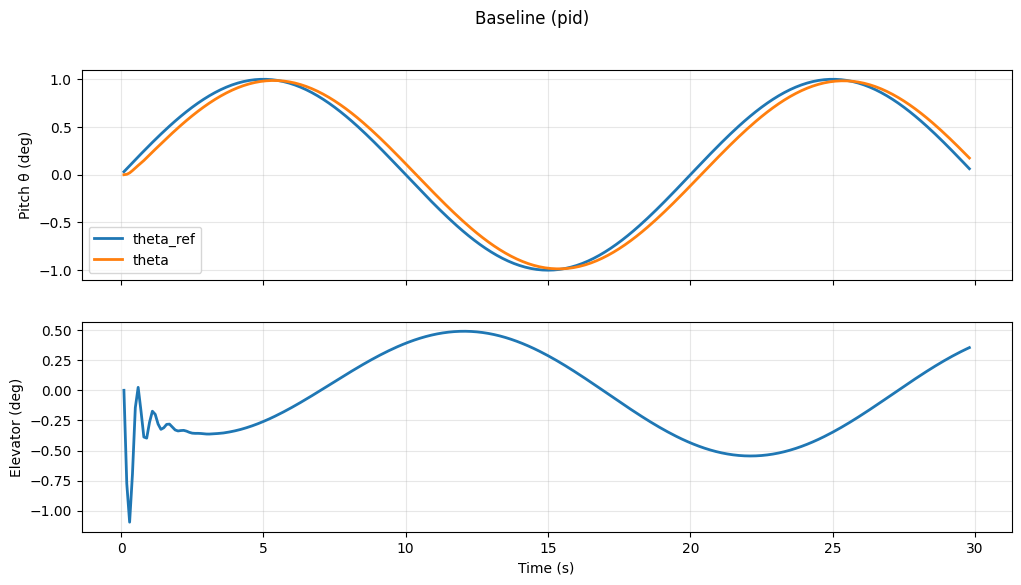

metrics: {'rmse_theta_deg': 0.08023503923903748, 'mae_theta_deg': 0.07220536125471365, 'max_abs_theta_deg': 0.11803107211676142, 'episode_return': -0.002675393092135713}


In [5]:
# Baseline controller (для сравнения)
# Важно: раньше тут был random policy; теперь baseline совпадает с выбранным baseline-контроллером.

baseline_env = make_env()
base_kind = DHP_BASELINE_TYPE if bool(DHP_USE_BASELINE) else "random"
baseline = rollout(baseline_env, agent=None, baseline=base_kind)
plot_rollout(baseline, title=f"Baseline ({base_kind})")



In [ ]:
# Create agent + train
# NOTE: do NOT override cycle lengths here; tune them in User controls.
# Recommended starting point from the paper: critic trained longer than actor (e.g., 5:1 or 10:1).
train_env = make_env()
agent = ADP(
    env=train_env,
    design=DESIGN,
    gamma=GAMMA,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    hidden_size=HIDDEN_SIZE,
    device=DEVICE,
    exploration_std=EXPLORATION_STD,
    use_replay=USE_REPLAY,
    memory_capacity=REPLAY_CAPACITY,
    batch_size=BATCH_SIZE,
    updates_per_step=UPDATES_PER_STEP,
    use_target_networks=USE_TARGET_NETWORKS,
    tau=TAU,
    log_every_updates=200,
    # DHP stability options
    dhp_use_env_cost=DHP_USE_ENV_COST,
    dhp_use_baseline=DHP_USE_BASELINE,
    dhp_baseline_type=DHP_BASELINE_TYPE,
    dhp_baseline_kp=DHP_BASELINE_KP,
    dhp_baseline_ki=DHP_BASELINE_KI,
    dhp_baseline_kd=DHP_BASELINE_KD,
    dhp_pid_use_normalized_theta=DHP_PID_USE_NORMALIZED_THETA,
    dhp_residual_scale=DHP_RESIDUAL_SCALE,
    dhp_critic_cycle_episodes=DHP_CRITIC_CYCLE_EPISODES,
    dhp_action_cycle_episodes=DHP_ACTION_CYCLE_EPISODES,
)

In [14]:

# Optional progress bar
try:
    from tqdm import tqdm  # type: ignore
except Exception:
    tqdm = None
TRAIN_EPISODES=500
print("Training... episodes:", TRAIN_EPISODES, "design:", DESIGN)

# Train in chunks and evaluate periodically (helps see whether learning is improving)
# Extra safety: keep the BEST actor weights by RMSE and rollback if training makes it worse.

from copy import deepcopy

best_rmse = float("inf")
best_actor_state = deepcopy(agent.actor.state_dict())

# Evaluate initial policy before any training
init = rollout(make_env(), agent=agent, deterministic=True)
best_rmse = float(init["metrics"]["rmse_theta_deg"])
print(f"initial eval: rmse_theta_deg={best_rmse:.3f}")

eval_returns = []
chunks = int(np.ceil(float(TRAIN_EPISODES) / float(max(1, int(EVAL_EVERY)))))
iterable = range(chunks) if tqdm is None else tqdm(range(chunks))
for k in iterable:
    n_ep = int(min(int(EVAL_EVERY), int(TRAIN_EPISODES) - k * int(EVAL_EVERY)))
    if n_ep <= 0:
        break

    agent.train(num_episodes=n_ep, max_steps=int(MAX_STEPS_PER_EPISODE))

    data = rollout(make_env(), agent=agent, deterministic=True)
    r = float(data["metrics"]["episode_return"])
    rmse = float(data["metrics"]["rmse_theta_deg"])
    term = bool(data.get("terminated", False))
    trunc = bool(data.get("truncated", False))
    eval_returns.append(r)

    # rollback if worse than best
    if rmse <= best_rmse:
        best_rmse = rmse
        best_actor_state = deepcopy(agent.actor.state_dict())
        tag = "(best)"
    else:
        agent.actor.load_state_dict(best_actor_state)
        tag = "(rollback)"

    print(
        f"after {min((k+1)*int(EVAL_EVERY), int(TRAIN_EPISODES))}/{int(TRAIN_EPISODES)} "
        f"episodes: return={r:.3f}, rmse_theta_deg={rmse:.3f} {tag}, terminated={term}, truncated={trunc}"
    )

# Ensure final policy is the best seen
agent.actor.load_state_dict(best_actor_state)
print("Done. Total updates:", getattr(agent, "_updates", None), "best_rmse:", best_rmse)



Training... episodes: 500 design: dhp
initial eval: rmse_theta_deg=0.137


  2%|▏         | 1/50 [00:16<13:26, 16.47s/it]

after 10/500 episodes: return=-0.006, rmse_theta_deg=0.120 (best), terminated=False, truncated=True


  4%|▍         | 2/50 [00:30<12:12, 15.27s/it]

after 20/500 episodes: return=-0.017, rmse_theta_deg=0.182 (rollback), terminated=False, truncated=True


...

after 480/500 episodes: return=-0.012, rmse_theta_deg=0.155 (rollback), terminated=False, truncated=True


 98%|█████████▊| 49/50 [13:00<00:16, 16.01s/it]

after 490/500 episodes: return=-0.011, rmse_theta_deg=0.152 (rollback), terminated=False, truncated=True


100%|██████████| 50/50 [13:16<00:00, 15.93s/it]

after 500/500 episodes: return=-0.011, rmse_theta_deg=0.149 (rollback), terminated=False, truncated=True
Done. Total updates: 149000 best_rmse: 0.11999378756753074


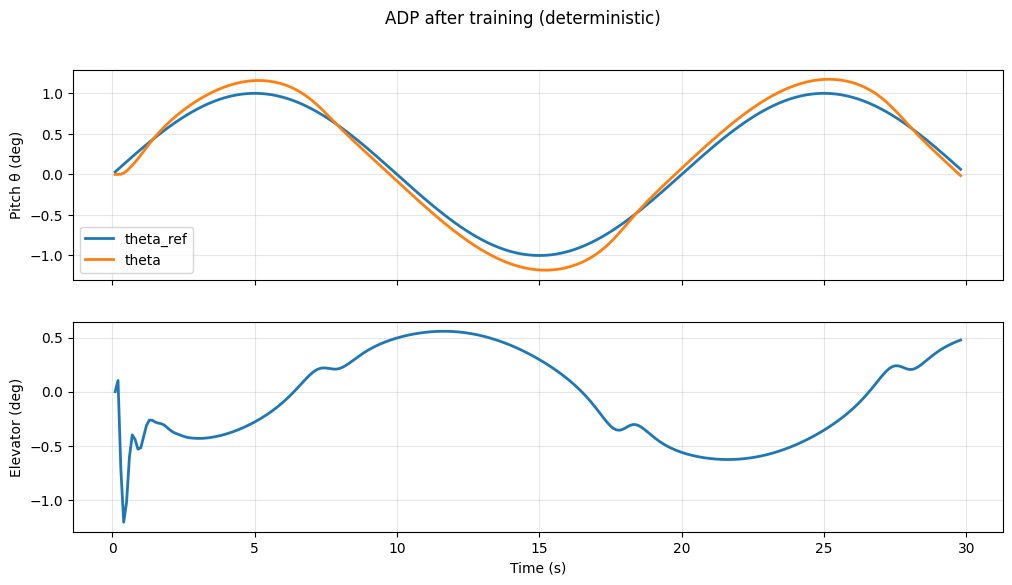

metrics: {'rmse_theta_deg': 0.11999378756753074, 'mae_theta_deg': 0.10916131627532559, 'max_abs_theta_deg': 0.19493706907815, 'episode_return': -0.0064847494812578805}


In [15]:
# Evaluation: deterministic policy (без шума)

eval_env = make_env()
trained = rollout(eval_env, agent=agent, deterministic=True)
plot_rollout(trained, title="ADP after training (deterministic)")



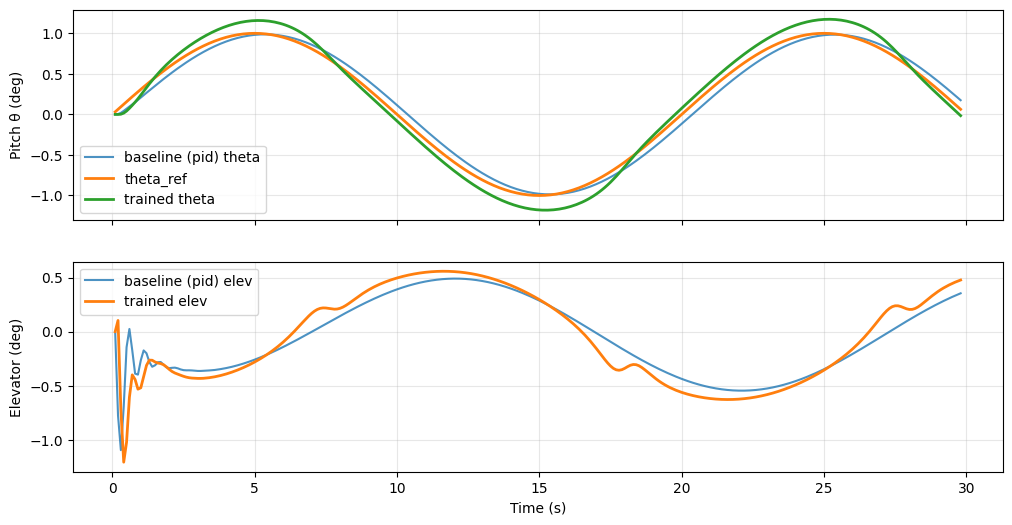

baseline metrics: {'rmse_theta_deg': 0.08023503923903748, 'mae_theta_deg': 0.07220536125471365, 'max_abs_theta_deg': 0.11803107211676142, 'episode_return': -0.002675393092135713}
trained metrics: {'rmse_theta_deg': 0.11999378756753074, 'mae_theta_deg': 0.10916131627532559, 'max_abs_theta_deg': 0.19493706907815, 'episode_return': -0.0064847494812578805}


In [16]:
# Compare baseline vs trained

fig, ax = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

ax[0].plot(baseline["t_s"], baseline["theta_deg"], label=f"baseline ({base_kind}) theta", alpha=0.8)
ax[0].plot(baseline["t_s"], baseline["theta_ref_deg"], label="theta_ref", linewidth=2)
ax[0].plot(trained["t_s"], trained["theta_deg"], label="trained theta", linewidth=2)
ax[0].set_ylabel("Pitch θ (deg)")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(baseline["t_s"], baseline["elev_deg"], label=f"baseline ({base_kind}) elev", alpha=0.8)
ax[1].plot(trained["t_s"], trained["elev_deg"], label="trained elev", linewidth=2)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Elevator (deg)")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.show()

print("baseline metrics:", baseline["metrics"])
print("trained metrics:", trained["metrics"])



## Notes

- The paper (Section III) recommends starting with a **stabilizing controller** and alternating critic and actor training cycles.
  To eliminate rare "catastrophic" failures (terminated episodes), this loop can be extended.
- Start with small number of episodes (`n_episodes=50`) for quick debugging, then scale up.
- Monitor TensorBoard logs (`runs/`) for reward and loss curves.